In [ ]:
# user specified parameters
K = 10 # number of passages
llm_backbone = "gpt-4o"
index = 100 # index of datapoint to test

In [ ]:
!pip install -U huggingface_hub

from huggingface_hub import hf_hub_download
import pickle

# Download from Hugging Face Hub
file_path = hf_hub_download(
    repo_id="Yuqicheng/ArgRAG",  # your dataset repo
    filename="PubHealth.pkl",    # the exact filename
    repo_type="dataset"
)

# Load the pickle file
with open(file_path, "rb") as f:
    data = pickle.load(f)

# get claim, contexts and ground truth answer
claim = data["claims"][index]
contexts = data["contexts"][index]
gt_answer = data["answers"][index]

In [ ]:
import json
from openai import OpenAI
from google.colab import userdata

EV2C_PROMPT = """
Task: Given a claim and multiple pieces of evidence, classify each evidence as "support", "contradict", or "irrelevant" to the claim.
Classify each evidence as either supporting, contradicting, or irrelevant to the claim.
Instructions:
- Support: Evidence that backs the claim.
- Contradict: Evidence that counters or limits the claim.
- Irrelevant: Evidence unrelated to the claim.
Output Format:
Return a single JSON object with three keys: "support", "contradict", and "irrelevant", each mapping to a list of evidence items.
Example format: {example}
Claim:
{claim}
Evidence:
{evidence}
You must always PROVIDE ONLY A SINGLE JSON without any additional explanation or commentary.
**Do not** include markdown formatting (such as triple backticks or `json` tags) in the output.
"""

EV2C_JSON_EXAMPLE = '{"support": ["E1"], "contradict": ["E3", "E4"], "irrelevant": ["E2", "E5"]}'

EV2EV_PROMPT = """
Task: Given a claim and multiple pieces of evidence, analyze the relationships between evidence with respect to the claim.
Instructions:
- Support: Two evidence items that reinforce each other regarding the claim.
- Contradict: Two evidence items that conflict with each other regarding the claim.
Output Format:
Return a single JSON object with two keys: "support" and "contradict", each mapping to a list of evidence pairs.
Example format: {example}
Claim:
{claim}
Evidence:
{evidence}
You must always PROVIDE ONLY A SINGLE JSON without any additional explanation or commentary.
**Do not** include markdown formatting (such as triple backticks or `json` tags) in the output.
"""

EV2EV_JSON_EXAMPLE = '{"support": [["E1", "E2"], ["E1", "E3"]], "contradict": [["E2", "E3"]]}'

def run_gpt_inference(prompt, model="gpt-3.5-turbo", temperature=0.7, max_tokens=10):
    """
    Runs inference using the OpenAI Chat API with a given prompt.
    """
    client = OpenAI(api_key=userdata.get('OPENAI_API_KEY'))

    try:
        completion = client.chat.completions.create(
            model=model,
            temperature=temperature,
            max_tokens=max_tokens,
            messages=[
                {
                    "role": "user",
                    "content": prompt
                }
            ]
        )
        return completion.choices[0].message.content
    except Exception as e:
        print(f"An error occurred: {e}")
        return None

def safe_json_loads(json_str):
    """
    Safely parse JSON that might have formatting issues common in LLM outputs.
    """
    # delete spaces in string
    json_str = json_str.replace(" ", "")

    try:
        # Try standard JSON parsing first
        return json.loads(json_str)
    except json.JSONDecodeError:
        # Fix common JSON formatting issues

        # 1. Fix unquoted evidence IDs
        fixed_str = json_str

        # Fix tuple/list formatting with unquoted identifiers
        # Match patterns like: (E2, E3) or [E2, E3]
        import re

        # Fix parentheses format (E1, E2) → ["E1", "E2"]
        fixed_str = re.sub(r'\((\w+),\s*(\w+)\)', r'["\1", "\2"]', fixed_str)

        # Fix unquoted array elements [E1, E2] → ["E1", "E2"]
        fixed_str = re.sub(r'\[(\w+),\s*(\w+)\]', r'["\1", "\2"]', fixed_str)

        # Fix standalone unquoted identifiers
        for key in ["support", "contradict", "irrelevant"]:
            # Match patterns like: "key": [E1, E2, E3]
            pattern = rf'"{key}":\s*\[(.*?)\]'
            match = re.search(pattern, fixed_str)
            if match:
                elements = match.group(1).split(',')
                quoted_elements = [f'"{e.strip()}"' for e in elements if e.strip()]
                replacement = f'"{key}": [{", ".join(quoted_elements)}]'
                fixed_str = re.sub(pattern, replacement, fixed_str)

        try:
            return json.loads(fixed_str)
        except json.JSONDecodeError as e:
            # If still failing, implement more aggressive fixes or log the error
            print(f"JSON parsing error after fixes: {e}")
            print(f"Original string: {json_str}")
            print(f"Fixed string attempt: {fixed_str}")

            # As a fallback, return a minimal valid structure
            return {}

In [ ]:
ev2c_prompt = EV2C_PROMPT.format_map({
        "example": EV2C_JSON_EXAMPLE,
        "claim": claim,
        "evidence": "".join(f"- E{i+1}: {ctx}\n" for i, ctx in enumerate(contexts[:K]))
        })
# print(ev2c_prompt)

arg_dict = {f"E{i+1}": ctx for i, ctx in enumerate(contexts[:K])}
arg_dict["Claim"] = claim
ev2c_answer = run_gpt_inference(ev2c_prompt, model=llm_backbone, temperature=0.0, max_tokens=512)
ev2c_dict = safe_json_loads(ev2c_answer)

ev2ev_prompt = EV2EV_PROMPT.format_map({
        "example": EV2EV_JSON_EXAMPLE,
        "claim": claim,
        "evidence": "".join(f"- {key}: {arg_dict[key]}\n" for i, key in enumerate(ev2c_dict["support"]+ev2c_dict["contradict"]))
        })
# print(ev2ev_prompt)

ev2ev_answer = run_gpt_inference(ev2ev_prompt, model=llm_backbone, temperature=0.0, max_tokens=512)
ev2ev_dict = safe_json_loads(ev2ev_answer)

print(f"Relationship between evidence and claim: \n{ev2c_dict}\n")
print(f"Relationship between evidences: \n{ev2ev_dict}")

Relationship between evidence and claim: 
{'support': ['E6', 'E8', 'E9'], 'contradict': ['E3'], 'irrelevant': ['E1', 'E2', 'E4', 'E5', 'E7', 'E10']}

Relationship between evidences: 
{'support': [['E6', 'E8'], ['E6', 'E9']], 'contradict': [['E3', 'E6']]}


In [ ]:
#!git clone https://github.com/ZhuYuqicheng/Argumentation.git
#%cd Argumentation
!git clone https://github.com/nicopotyka/Uncertainpy.git
%cd Uncertainpy

Cloning into 'Uncertainpy'...
remote: Enumerating objects: 601, done.
remote: Counting objects: 100% (148/148), done.
remote: Compressing objects: 100% (121/121), done.
remote: Total 601 (delta 91), reused 26 (delta 26), pack-reused 453 (from 1)
Receiving objects: 100% (601/601), 1.02 MiB | 3.04 MiB/s, done.
Resolving deltas: 100% (317/317), done.
/content/Uncertainpy/Uncertainpy/Uncertainpy


In [ ]:
import os
import sys
sys.path.append("src")
import networkx as nx
import uncertainpy.gradual as grad
from uncertainpy.gradual.Argument import Argument

def ArgRAG_pred(ev2c_dict, ev2ev_dict, arg_dict, arg_model):
    evidence = ev2c_dict["support"] + ev2c_dict["contradict"]
    # if evidence is empty, return param_pred
    if len(evidence) == 0:
        return "use parametric answer", []
    else:
        G = nx.DiGraph()

        # define nodes
        G.add_node("claim", type="claim", text=arg_dict["Claim"])
        for i, ev in enumerate(evidence):
            G.add_node(ev, type="evidence", text=arg_dict[f"E{i+1}"])

        # define edges
        for sup in ev2c_dict["support"]:
            G.add_edge(sup, "claim", relation="support")
        for att in ev2c_dict["contradict"]:
            G.add_edge(att, "claim", relation="attack")

        if len(ev2ev_dict["support"]) != 0:
            for ev1, ev2 in ev2ev_dict["support"]:
                G.add_edge(ev1, ev2, relation="support")
                G.add_edge(ev2, ev1, relation="support")
        if len(ev2ev_dict["contradict"]) != 0:
            for ev1, ev2 in ev2ev_dict["contradict"]:
                G.add_edge(ev1, ev2, relation="attack")
                G.add_edge(ev2, ev1, relation="attack")

        bag = grad.BAG()
        # specify nodes
        for id, meta in G.nodes(data=True):
            argument = Argument(id, 0.5)
            bag.arguments[id] = argument
        # specify edges
        for u, v, d in G.edges(data=True):
            if d["relation"] == "support":
                bag.add_support(bag.arguments[u], bag.arguments[v])
            elif d["relation"] == "attack":
                bag.add_attack(bag.arguments[u], bag.arguments[v])

        arg_model.BAG = bag
        arg_model.approximator = grad.algorithms.RK4(arg_model)
        arg_model.solve(delta=10e-2, epsilon=10e-4, verbose=False, generate_plot=False)

        arg_strengths = {x.name: x.strength for x in arg_model.BAG.arguments.values()}

        G.nodes["claim"]["strength"] = arg_strengths["claim"]
        for i, ev in enumerate(evidence):
            G.nodes[ev]["strength"] = arg_strengths[ev]

        if arg_strengths["claim"] >= 0.5:
            return "true", G
        else:
            return "false", G

arg_model = grad.semantics.ContinuousDFQuADModel()
Arg_pred, G = ArgRAG_pred(ev2c_dict, ev2ev_dict, arg_dict, arg_model)
print(f"ArgRAG predcition: {Arg_pred}")
print(f"Ground Truth: {gt_answer}")

ArgRAG predcition: true
Ground Truth: true


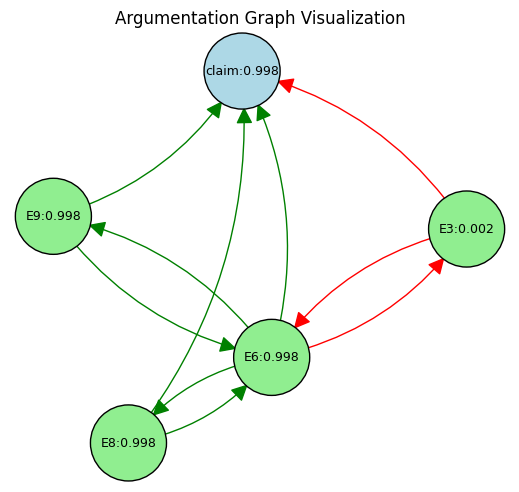

claim: Massachusetts lawmakers weigh ‘Medicare for all’ bill.
E6: Massachusetts health care reform: to operate an expanded Medicaid program. Under the existing waiver, the state was receiving $385 million in federal funds to reimburse hospitals for services provided to the uninsured. The free care pool had to be restructured so that individuals, rather than institutions, received the funding. Then-U.S. Senator Edward Kennedy (D-MA) made a special effort to broker a compromise between the Republican Governor and the Democratic State Legislature. In Fall 2005, the House and Senate each passed health care insurance reform bills. The legislature made a number of changes to Governor Romney's original proposal, including expanding MassHealth (Medicaid and SCHIP) coverage
E8: Massachusetts health care reform: Care Today) Coalition introduced a bill that expanded MassHealth (Medicaid and SCHIP) coverage and increased health coverage subsidy programs and required employers to either provide cov

In [ ]:
import matplotlib.pyplot as plt
import textwrap

def visualize_graph(G):
    plt.figure(figsize=(5, 5))

    # Define node colors based on type
    node_colors = {'claim': 'lightblue', 'evidence': 'lightgreen'}
    edge_colors = {'support': 'green', 'attack': 'red'}

    # Get node positions
    pos = nx.spring_layout(G, seed=42)

    # Draw nodes
    node_types = nx.get_node_attributes(G, 'type')
    node_labels = nx.get_node_attributes(G, 'text')
    node_strengths = nx.get_node_attributes(G, 'strength')
    node_color_list = [node_colors[node_types[n]] for n in G.nodes]

    nx.draw_networkx_nodes(G, pos, node_color=node_color_list, node_size=3000, edgecolors='black')

    # Draw edges with different colors
    edge_labels = nx.get_edge_attributes(G, 'relation')
    edge_color_list = [edge_colors[edge_labels[e]] for e in G.edges]

    nx.draw_networkx_edges(G, pos, edge_color=edge_color_list, arrows=True, arrowsize=25, arrowstyle='-|>', connectionstyle="arc3,rad=0.2", min_target_margin=26, min_source_margin=26)

    # Draw labels
    # wrapped_labels = {node: '\n'.join(textwrap.wrap(label, width=30)) for node, label in node_labels.items()}
    wrapped_labels = {
        node: '\n'.join(textwrap.wrap(f"{node}:{score:.3f}", width=30))
        for node, score in zip(G.nodes, node_strengths.values())
    }

    nx.draw_networkx_labels(G, pos, labels=wrapped_labels, font_size=9, verticalalignment='center')
    # nx.draw_networkx_labels(G, pos, font_size=9, verticalalignment='center')

    plt.title("Argumentation Graph Visualization")
    plt.subplots_adjust(left=0.5, right=1.5, top=0.9, bottom=0.0)
    plt.axis("off")
    plt.show()

    for node, label in node_labels.items():
      print(f"{node}: {label}")

if G:
  visualize_graph(G)
else:
  print("No graph to visualize.")